# EDA · bronze_unificado -- contraste de decisiones y calidad de datos
Cada apartado de la lista de verificación queda como un bloque autocontenido:
**contexto -> decisión -> evidencia -> consecuencia**. La evidencia corre contra
`bronze_unificado.parquet` real, no se cita de memoria lo que ya documentó el equipo --
si el resultado coincide, queda confirmado con datos propios; si no coincide, es
información para la reunión, no algo para esconder.

**Nulos y huecos son información, no bugs.** Esta capa no imputa nada -- lo que aparece
en `NaN` es evidencia para decidir en silver, no un error de este notebook.

## Índice de bloques
- **A.1** D-02 -- el gas de ENTSO-E vs. ESIOS (colinealidad, offset inestable)
- **A.2** D-03 -- autoconsumo en la demanda (`ree_load` vs `entsoe_load`)
- **A.3** D-03 -- autoconsumo en la solar (`ree_gsolar_mw` vs `entsoe_solar_mw`)
- **A.4** Pendiente: D-01 (potencia disponible con fuga) y D-04 (columnas constantes) -- necesitan `esios_capacity_*` y `esios_capacity_available_fc`, todavía fuera del bronce
- **B** Perfil general de nulos, tabla por tabla
- **C** Distribuciones y outliers
- **D** Cobertura temporal y bordes de cambio de hora (DST)
- **E** Consistencia cruzada pendiente (eólica, hidráulica) -- necesita columnas no incluidas todavía

*Working directory: `notebooks/` (para importar `bronze_config` desde `scripts/`).*

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("..").resolve() / "scripts"))
from bronze_config import BRONZE_DIR, UNIFIED_FILENAME, TABLES

%matplotlib inline
pd.set_option("display.max_columns", None)

## 0 · Carga y panorama general

In [29]:
df = pd.read_parquet(BRONZE_DIR / UNIFIED_FILENAME)

print(f"Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango temporal: {df['ts_utc'].min()} -> {df['ts_utc'].max()}")

def origen(col):
    if col in ("ts_utc", "ts_local", "date_utc", "date_local", "hour_utc", "hour_local"):
        return "calendario"
    if col.startswith("calc_"):
        return "derivada"
    return col.split("_")[0] if not col.startswith(("esios_gen", "esios_forecast")) else "_".join(col.split("_")[:2])

pd.Series(df.columns).apply(origen).value_counts()

Shape: 1,393,183 filas x 83 columnas
Rango temporal: 2020-01-01 00:00:00+00:00 -> 2026-08-15 23:00:00+00:00


cap            24
load           13
entsoe         11
esios_gen      10
era5            9
calendario      6
forecast        4
commodities     3
derivada        3
Name: count, dtype: int64

---
## A.1 · D-02 -- el gas de ENTSO-E y el de ESIOS no son intercambiables

**Contexto:** `entsoe_gas_mw` (B04) mezcla ciclo combinado + cogeneración. ESIOS separa
`ree_gccgas_mw` (CCGT puro) de `ree_gotherthermal_mw` (cogeneración y resto). Si la suma
de ESIOS reproduce el B04, las fuentes son intercambiables.

**Decisión documentada:** usar ESIOS con las dos columnas separadas -- el CCGT marca el
precio marginal, la cogeneración es inelástica. `entsoe_gas_mw` se descarta del dataset
de modelado (queda en el bronce solo para esta verificación).

Correlación entsoe_gas vs ree_gccgas solo:   0.97882
Correlación entsoe_gas vs suma ESIOS:        0.99626

Diferencia media vs. CCGT solo: 1894.6 MW
Diferencia media vs. suma:      -374.8 MW


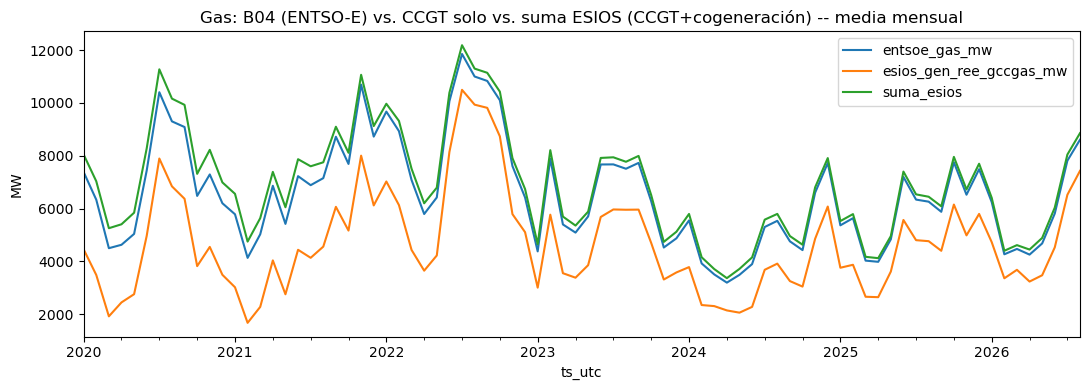

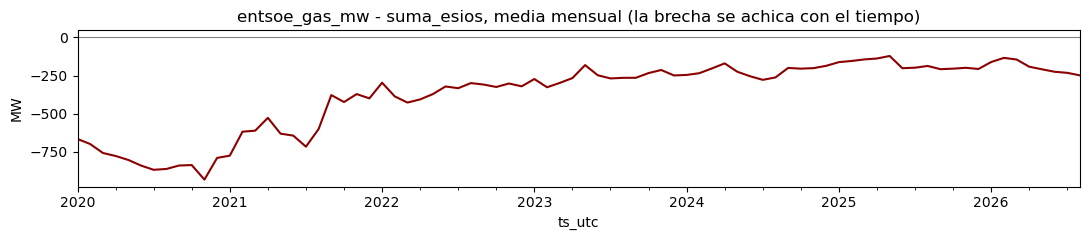

In [30]:
gas = df[["ts_utc", "entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "esios_gen_ree_gotherthermal_mw"]].dropna()
gas["suma_esios"] = gas["esios_gen_ree_gccgas_mw"] + gas["esios_gen_ree_gotherthermal_mw"]
gas["diff_vs_ccgt_solo"] = gas["entsoe_gas_mw"] - gas["esios_gen_ree_gccgas_mw"]
gas["diff_vs_suma"] = gas["entsoe_gas_mw"] - gas["suma_esios"]

print("Correlación entsoe_gas vs ree_gccgas solo:  ", gas["entsoe_gas_mw"].corr(gas["esios_gen_ree_gccgas_mw"]).round(5))
print("Correlación entsoe_gas vs suma ESIOS:       ", gas["entsoe_gas_mw"].corr(gas["suma_esios"]).round(5))
print()
print("Diferencia media vs. CCGT solo:", gas["diff_vs_ccgt_solo"].mean().round(1), "MW")
print("Diferencia media vs. suma:     ", gas["diff_vs_suma"].mean().round(1), "MW")

gas.set_index("ts_utc")[["entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "suma_esios"]].resample("MS").mean().plot(
    figsize=(11, 4), title="Gas: B04 (ENTSO-E) vs. CCGT solo vs. suma ESIOS (CCGT+cogeneración) -- media mensual"
)
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# El crudo horario (58k+ puntos, 6 años) hace que suma_esios (dibujada última) tape a
# entsoe_gas_mw casi todo el tiempo -- estan muy cerca entre si. El hallazgo real de D-02
# no es "se solapan", es que la brecha se achica con el tiempo -- eso se ve directo acá:
gas.set_index("ts_utc")["diff_vs_suma"].resample("MS").mean().plot(
    figsize=(11, 2.5), title="entsoe_gas_mw - suma_esios, media mensual (la brecha se achica con el tiempo)", color="darkred"
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.ylabel("MW")
plt.tight_layout()
plt.show()

In [31]:
gas["año"] = gas["ts_utc"].dt.year
por_año = gas.groupby("año")[["entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "esios_gen_ree_gotherthermal_mw"]].mean().round(0)
por_año["diferencia"] = (por_año["entsoe_gas_mw"] - por_año["esios_gen_ree_gccgas_mw"] - por_año["esios_gen_ree_gotherthermal_mw"]).round(0)
por_año

,entsoe_gas_mw,esios_gen_ree_gccgas_mw,esios_gen_ree_gotherthermal_mw,diferencia
año,,,,
2020,7010.0,4416.0,3400.0,-806.0
2021,7035.0,4358.0,3235.0,-558.0
2022,8818.0,6964.0,2196.0,-342.0
2023,6210.0,4546.0,1920.0,-256.0
2024,4830.0,3314.0,1738.0,-222.0
2025,5950.0,4427.0,1701.0,-178.0
2026,5593.0,4441.0,1342.0,-190.0


**Consecuencia:** si la correlación contra la suma es notablemente más alta que contra
el CCGT solo, y el offset cambia año a año (según la tabla de arriba), queda confirmado
que (a) el B04 es la suma, no el CCGT puro, y (b) el offset no es estable -- no se puede
usar una fuente en train y otra en test sin introducir un sesgo que cambia con el tiempo.

Si los números no coinciden con lo documentado en D-02 (correlación ~0,996 contra la
suma, offset cayendo de ~2.600 MW en 2020 a ~1.150 MW en 2026), es señal de que el
esquema real difiere de cuando se escribió esa decisión -- ver hallazgo de `datetime_utc`
vs `datetime` en `entsoe_gen_data`.

---
## A.2 · D-03 -- autoconsumo en la demanda

**Contexto:** `ree_load` y `entsoe_load` medían lo mismo hasta que REE empezó a sumarle
una estimación de autoconsumo a `ree_load` desde diciembre de 2025.

**Decisión documentada:** usar `entsoe_load` para modelar. `ree_load` se conserva -- su
diferencia con `entsoe_load` (`calc_autoconsumo_mw`, ya calculada en el bronce) estima el
autoconsumo peninsular, no es una segunda candidata a "demanda real".

**Nota de método:** el perfil horario se calcula solo sobre el período donde el fenómeno
está presente (dic-2025 en adelante) -- promediar todo el histórico mezcla 71 meses de
ruido de fondo (pre-quiebre) con los 9 meses donde el efecto es real, y distorsiona el
patrón horario resultante.

In [32]:
demanda = df[["ts_utc", "load_inter_ree_load", "load_inter_entsoe_load", "calc_autoconsumo_mw"]].dropna()
demanda["mes"] = demanda["ts_utc"].dt.to_period("M")

por_mes = demanda.groupby("mes")["calc_autoconsumo_mw"].mean().round(1)
print("Autoconsumo medio por mes (MW) -- buscar el mes donde deja de ser ~0:")
print(por_mes.to_string())

Autoconsumo medio por mes (MW) -- buscar el mes donde deja de ser ~0:
mes
2020-01     -13.5
2020-02     -11.8
2020-03      -5.8
2020-04      -6.6
2020-05      -7.9
2020-06      -5.6
2020-07      -6.1
2020-08      -3.9
2020-09      -9.9
2020-10      -9.2
2020-11     -12.8
2020-12      -4.6
2021-01      -8.3
2021-02     -12.5
2021-03     -10.5
2021-04     -13.6
2021-05     -13.7
2021-06     -16.5
2021-07     -10.2
2021-08      -7.7
2021-09      -7.5
2021-10      -6.6
2021-11     -11.4
2021-12      -6.8
2022-01      -7.0
2022-02      -9.4
2022-03      -5.0
2022-04      -6.9
2022-05       1.3
2022-06      -5.6
2022-07      -1.5
2022-08      -1.5
2022-09      -6.3
2022-10      -8.9
2022-11      -4.2
2022-12      -0.4
2023-01      -2.4
2023-02      -4.6
2023-03      -4.6
2023-04      -7.9
2023-05      -4.8
2023-06      -3.5
2023-07      -3.3
2023-08      -3.7
2023-09      -6.0
2023-10      -3.6
2023-11      -2.2
2023-12      -2.3
2024-01      -4.8
2024-02      -2.3
2024-03      -4.7
2024-04 

C:\Users\lhern\AppData\Local\Temp\ipykernel_15212\1429878849.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  demanda["mes"] = demanda["ts_utc"].dt.to_period("M")


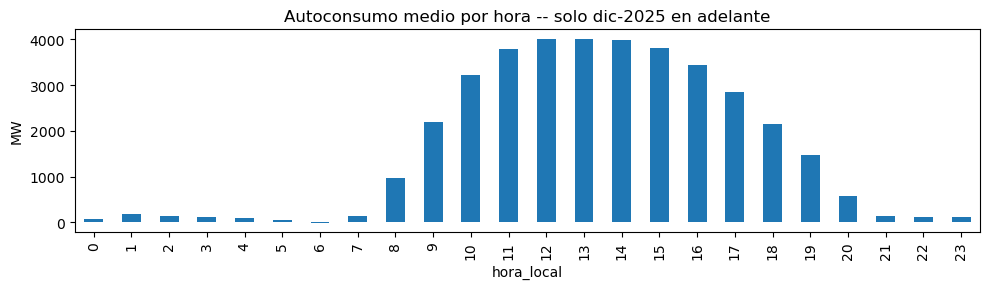

In [33]:
demanda_reciente = demanda[demanda["ts_utc"] >= "2025-12-01"].copy()
demanda_reciente["hora_local"] = demanda_reciente["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour
por_hora = demanda_reciente.groupby("hora_local")["calc_autoconsumo_mw"].mean()

por_hora.plot(kind="bar", figsize=(10, 3), title="Autoconsumo medio por hora -- solo dic-2025 en adelante")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

**Consecuencia:** si `por_mes` muestra un salto de ~0 a varios cientos de MW en
diciembre-2025, y `por_hora` (ya acotado al período posterior) dibuja una campana con pico
a mediodía, queda confirmado el patrón de autoconsumo fotovoltaico documentado en D-03 --
con evidencia propia, no heredada.

---
## A.3 · D-03 -- autoconsumo en la solar

**Contexto:** mismo fenómeno que A.2, del lado de generación. `ree_gsolar_mw` (FV de
ESIOS) incorpora la misma estimación de autoconsumo, con la misma magnitud y el mismo mes
de quiebre -- porque el autoconsumo entra por los dos lados del balance.

**Decisión documentada:** no usar `ree_gsolar_mw` directo. La FV limpia se reconstruye
como `calc_solar_fv_mw = GREATEST(0, entsoe_solar_mw - esios_gen_ree_gsolter_mw)` -- ya
calculada en el bronce.

**Importante:** la comparación correcta es contra `calc_solar_fv_mw` (la FV ya limpia de
termosolar), no contra `entsoe_solar_mw` directo -- esta última es la agregada FV+termosolar,
y restarla sin quitar la termosolar antes contamina la diferencia con la estacionalidad de
la termosolar (fuerte en verano, casi nula en invierno), simulando un problema que no existe.

In [34]:
solar = df[["ts_utc", "entsoe_solar_mw", "esios_gen_ree_gsolar_mw", "esios_gen_ree_gsolter_mw", "calc_solar_fv_mw"]].dropna()
solar["diff_entsoe_vs_esios_fv"] = solar["esios_gen_ree_gsolar_mw"] - solar["calc_solar_fv_mw"]
solar["mes"] = solar["ts_utc"].dt.to_period("M")

por_mes_solar = solar.groupby("mes")["diff_entsoe_vs_esios_fv"].mean().round(1)
print("Diferencia media ree_gsolar_mw - calc_solar_fv_mw, por mes:")
print(por_mes_solar.to_string())

Diferencia media ree_gsolar_mw - calc_solar_fv_mw, por mes:
mes
2020-01      -1.0
2020-02      -1.0
2020-03      -0.4
2020-04      -1.5
2020-05      -1.1
2020-06      -0.6
2020-07      -0.7
2020-08      -1.0
2020-09      -1.0
2020-10      -0.5
2020-11      -1.1
2020-12      -0.8
2021-01      -0.9
2021-02      -1.4
2021-03      -1.0
2021-04      -0.6
2021-05      -0.7
2021-06      -1.0
2021-07      -0.9
2021-08      -0.5
2021-09      -0.2
2021-10      -1.5
2021-11      -1.2
2021-12      -1.2
2022-01      -0.3
2022-02      -1.8
2022-03      -0.7
2022-04      -0.4
2022-05      -3.4
2022-06       0.3
2022-07       0.6
2022-08       1.0
2022-09       1.1
2022-10      -0.8
2022-11       1.3
2022-12       0.9
2023-01       1.3
2023-02       1.2
2023-03       1.3
2023-04       0.8
2023-05       1.6
2023-06       1.8
2023-07       1.0
2023-08       0.2
2023-09       1.6
2023-10       1.2
2023-11       2.3
2023-12       2.0
2024-01       2.9
2024-02       1.2
2024-03       2.7
2024-04       2.4


C:\Users\lhern\AppData\Local\Temp\ipykernel_15212\1171748023.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  solar["mes"] = solar["ts_utc"].dt.to_period("M")


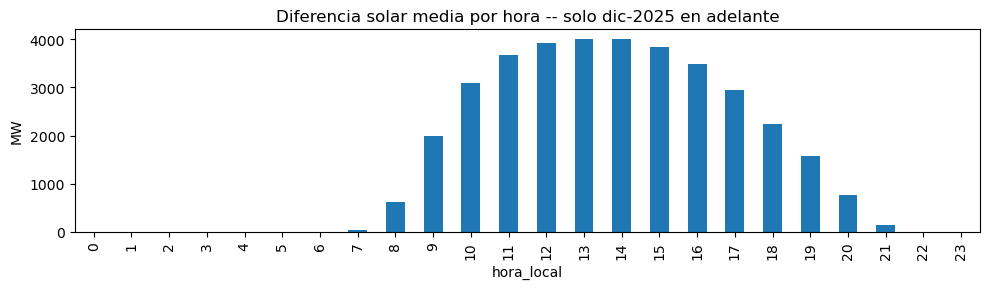

In [35]:
solar_reciente = solar[solar["ts_utc"] >= "2025-12-01"].copy()
solar_reciente["hora_local"] = solar_reciente["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour
por_hora_solar = solar_reciente.groupby("hora_local")["diff_entsoe_vs_esios_fv"].mean()

por_hora_solar.plot(kind="bar", figsize=(10, 3), title="Diferencia solar media por hora -- solo dic-2025 en adelante")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

**Consecuencia:** comparar el mes de quiebre de `por_mes_solar` contra el de `por_mes`
en A.2 -- D-03 afirma que ambas rompen **el mismo mes y con magnitud similar**, porque es
el mismo autoconsumo entrando por dos lados del balance. Si los meses de quiebre no
coinciden, vale la pena investigar antes de dar la decisión por confirmada.

---
## A.4 · D-04 -- columnas constantes y limpieza

**Contexto:** la auditoría de calidad encontró varias columnas de `esios_capacity_installed`
y `esios_capacity_available` con varianza cero en más de seis años de histórico, más un
indicador (`autoconsume_battery_mw`) sospechosamente congelado.

**Decisión documentada:** las columnas constantes no se borran de la base (el dato es
correcto -- España no conectó nucleares ni CCGT nuevos desde 2020), pero se excluyen del
conjunto de features -- una varianza cero no puede explicar nada en un modelo.
`autoconsume_battery_mw` se descarta como feature por indicador congelado en origen (el
2366, clavado en 5,00 MW). `autoconsume_solar_pv_mw` sirve además de validación cruzada
de D-03 (crece de 25 a 9.100 MW, coherente con la estimación de autoconsumo).

In [36]:
cols_capacidad = [c for c in df.columns if c.startswith(("cap_disp_", "cap_inst_"))]
assert cols_capacidad, (
    "No hay columnas cap_disp_*/cap_inst_* en el bronce todavia -- "
    "correr 'python scripts/extract_bronze.py' y despues 01_union_bronze.ipynb "
    "antes de esta celda."
)
varianzas = df[cols_capacidad].agg(["nunique", "std", "mean"]).T.sort_values("nunique")
varianzas

,nunique,std,mean
cap_inst_pump_mw,1.0,3.527051e-09,3331.400000
cap_disp_fuel_mw,1.0,7.625077e-12,7.900000
cap_inst_autoconsume_battery_mw,1.0,0.000000e+00,5.000000
cap_inst_nuclear_mw,1.0,5.743509e-09,7117.290000
cap_inst_fuel_mw,1.0,7.751200e-12,7.950000
cap_inst_ccgt_mw,1.0,1.087401e-08,24561.850000
cap_inst_waste_renewable_mw,2.0,4.732457e+00,129.536194
cap_inst_waste_nonrenewable_mw,8.0,9.901350e+00,391.888404
cap_inst_battery_hybrid_mw,8.0,6.400144e+01,42.484115
cap_inst_coal_mw,11.0,2.316270e+03,3559.764706


**Consecuencia:** las columnas con `nunique == 1` (o `std` prácticamente cero) confirman
D-04 -- son correctas pero inútiles como feature. Como este barrido corre sobre **las 25
columnas de capacidad** (no solo las que D-04 ya nombraba), cualquier columna constante
que aparezca acá y no esté en la lista original de D-04 es un hallazgo nuevo -- la
auditoría de calidad original ya dejaba esa puerta abierta ("hay más de 4 sin
documentar"). Si alguna de las ya documentadas muestra `nunique > 1`, es señal de que la
fuente cambió desde que se escribió D-04 (agregar planta, descongelar el indicador).

In [37]:
solar_pv_inst = df[["ts_utc", "cap_inst_autoconsume_solar_pv_mw"]].dropna()
solar_pv_inst["año"] = solar_pv_inst["ts_utc"].dt.year
solar_pv_inst.groupby("año")["cap_inst_autoconsume_solar_pv_mw"].agg(["min", "max", "nunique"])

,min,max,nunique
año,,,
2020,25.58,481.68,13
2021,481.68,800.05,13
2022,800.05,1991.19,13
2023,1991.19,4011.27,13
2024,4011.27,6696.74,13
2025,6696.74,8560.49,13
2026,8560.49,9113.42,8


**Validación cruzada con D-03:** si `autoconsume_solar_pv_mw` crece de forma sostenida
año a año (a diferencia de las columnas constantes de arriba), refuerza la estimación de
autoconsumo de A.2/A.3 -- confirmado por una tabla de potencia instalada que no interviene
en aquel cálculo, no por la misma resta de series horarias.

### D-01 -- pendiente, necesita `esios_capacity_available_fc`

No se puede verificar todavía: `esios_capacity_available_fc` tiene clave `(run_date,
target_date)`, que no encaja en el modelo de `grain` actual (asume una sola fecha por
fila). Verificar D-01 de verdad -- ¿el horizonte declarado varía entre capturas, o es un
valor plano propagado? -- necesita lógica de extracción propia (filtrar por
`run_date = target_date - 1 día`, mismo patrón que `_features_forecast` del maestro),
no un `grain` más en `bronze_config.TABLES`. Queda para un paso aparte.

---
## A.5 · ¿`demanda_residual_prev_mw` también arrastra autoconsumo?

**Contexto:** el maestro ya excluye esta columna, pero por otro motivo (revisión 10-14
días tras publicada, no por autoconsumo). `demanda_mercado_prev_mw` está documentada como
"sin autoconsumo" -- sirve de vara de comparación limpia. Si `demanda_residual_prev_mw`
tuviera el mismo quiebre de diciembre-2025 que `ree_load`/`ree_gsolar_mw` (A.2/A.3), sería
evidencia de que también está contaminada, más allá del problema de revisión ya conocido.

In [38]:
cols_a5 = ["forecast_demanda_residual_prev_mw", "forecast_demanda_mercado_prev_mw"]
assert all(c in df.columns for c in cols_a5), (
    "Falta forecast_demanda_residual_prev_mw en el bronce todavia -- "
    "correr 'python scripts/extract_bronze.py' y despues 01_union_bronze.ipynb "
    "antes de esta celda."
)
residual = df[["ts_utc"] + cols_a5].dropna()
residual["diff"] = residual["forecast_demanda_residual_prev_mw"] - residual["forecast_demanda_mercado_prev_mw"]
residual["mes"] = residual["ts_utc"].dt.to_period("M")

por_mes_residual = residual.groupby("mes")["diff"].mean()
print(por_mes_residual.to_string())

mes
2020-01    -7129.279435
2020-02    -7661.860201
2020-03    -9111.077957
2020-04    -6962.792917
2020-05    -8214.260618
2020-06    -8049.354167
2020-07    -9151.954704
2020-08    -8170.258871
2020-09    -8129.419722
2020-10    -9692.957335
2020-11    -6983.005833
2020-12   -10860.989919
2021-01   -10780.108468
2021-02   -10983.349256
2021-03   -10103.038900
2021-04    -8272.570417
2021-05   -10180.198387
2021-06    -9016.591944
2021-07   -10127.646371
2021-08    -8894.284812
2021-09    -7458.804583
2021-10    -8431.360969
2021-11   -10795.416944
2021-12   -10564.947312
2022-01    -9368.591129
2022-02    -9409.591815
2022-03   -10613.014883
2022-04   -11403.321528
2022-05   -11199.790390
2022-06   -10057.412639
2022-07   -10984.414819
2022-08   -10404.245800
2022-09    -9787.456319
2022-10    -9511.052086
2022-11   -11283.828646
2022-12    -9022.874899
2023-01   -12150.470699
2023-02   -10080.883705
2023-03   -13241.334306
2023-04   -12500.677465
2023-05   -12749.069355
2023-06   -1

C:\Users\lhern\AppData\Local\Temp\ipykernel_15212\311946997.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  residual["mes"] = residual["ts_utc"].dt.to_period("M")


**Consecuencia:** si la diferencia se mantiene relativamente estable en el tiempo (sin
un salto marcado en diciembre-2025), no hay evidencia de contaminación de autoconsumo --
la diferencia observada sería la resta de renovables que "residual" implica
conceptualmente, no autoconsumo. Si aparece el mismo patrón de ruptura que en A.2/A.3, es
un hallazgo nuevo que vale la pena llevar al equipo -- confirmaría un segundo motivo,
independiente de la revisión 10-14 días, para mantener esta columna fuera del dataset.

---
## B · Perfil de nulos por columna
Umbrales orientativos: >5% para revisar, >20% para tratar como posible limitante de uso
directo.

In [39]:
nulos = (
    df.isna().mean().mul(100).round(2).sort_values(ascending=False)
    .rename("pct_nulos").to_frame()
)
nulos["nivel"] = pd.cut(
    nulos["pct_nulos"], bins=[-0.1, 5, 20, 100],
    labels=["ok (<5%)", "revisar (5-20%)", "alerta (>20%)"],
)
nulos[nulos["pct_nulos"] > 0]

,pct_nulos,nivel
cap_inst_battery_hybrid_mw,98.35,alerta (>20%)
cap_inst_wind_hybrid_mw,98.29,alerta (>20%)
cap_inst_solar_pv_hybrid_mw,97.98,alerta (>20%)
cap_inst_autoconsume_battery_mw,97.93,alerta (>20%)
commodities_co2_eua_dec,97.09,alerta (>20%)
commodities_gas_ttf_m1,97.08,alerta (>20%)
cap_disp_fuel_mw,95.83,alerta (>20%)
cap_disp_ccgt_mw,95.83,alerta (>20%)
cap_inst_other_renewable_mw,95.83,alerta (>20%)
cap_inst_solar_pv_mw,95.83,alerta (>20%)


**Mapa de cobertura por columna y mes, separado por grano temporal** -- un panel
horario, uno diario y uno de 3h, cada uno midiendo presencia con la vara que le
corresponde (horas/mes, días/mes, pasos de 3h/mes). Mezclar granos en un solo mapa medido
por hora dejaba las tablas `daily` casi blancas aunque estuvieran completas (1 de cada 24
horas tiene valor por diseño) y diluía el matiz real de `era5` (3h). Separados, cada panel
debería verse negro parejo donde la cobertura es completa -- las franjas verticales que
empiezan a mitad del histórico (baterías desde 2025, categorías híbridas de capacidad
instalada desde 2023) son las que deberían saltar a la vista.

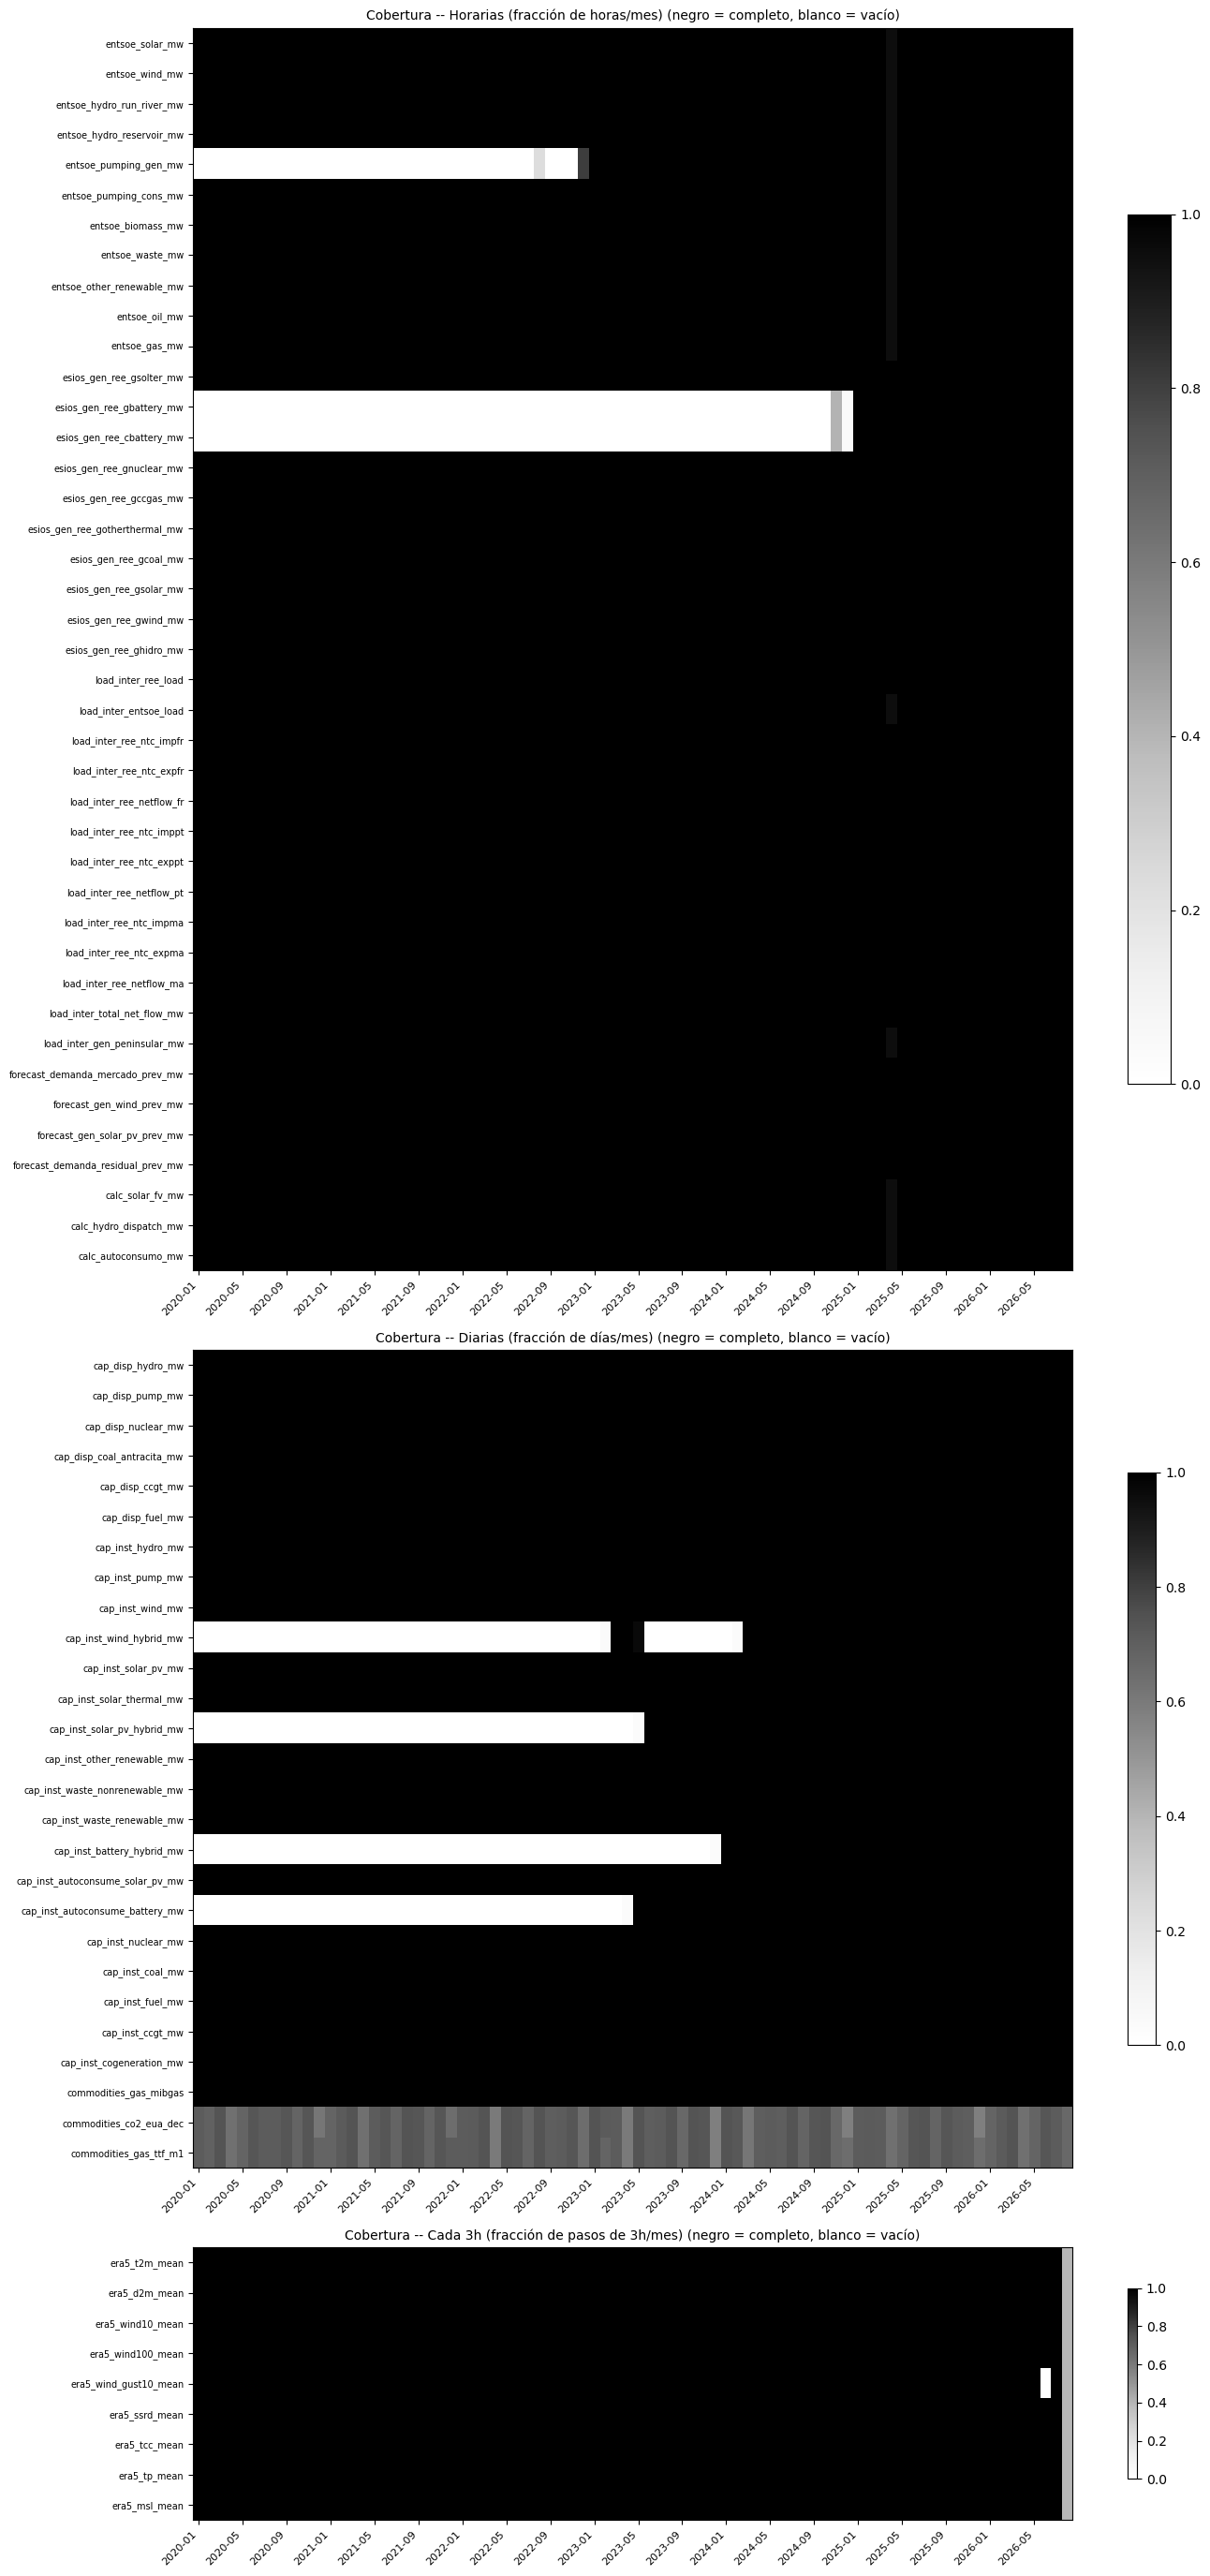

In [40]:
cols_cobertura = [c for c in df.columns if c not in ("ts_utc", "ts_local", "date_utc", "date_local", "hour_utc", "hour_local")]

# Cada columna se clasifica por el grain de su tabla de origen (bronze_config.TABLES) --
# las derivadas (calc_*) se tratan como hourly, ya que sus inputs lo son.
prefix_a_grain = {cfg["prefix"]: cfg.get("grain", "hourly") for cfg in TABLES.values()}

def grain_de_columna(col):
    for prefix, grain in sorted(prefix_a_grain.items(), key=lambda x: -len(x[0])):
        if col.startswith(prefix + "_"):
            return grain
    return "hourly"

grupos_grain = {"hourly": [], "daily": [], "3h": []}
for c in cols_cobertura:
    grupos_grain[grain_de_columna(c)].append(c)

def cobertura_mensual(cols, grain):
    base = df.set_index("ts_utc")[cols].notna()
    if grain == "hourly":
        return base.resample("MS").mean()
    freq = {"daily": "D", "3h": "3h"}[grain]
    return base.resample(freq).max().resample("MS").mean()

titulos = {"hourly": "Horarias (fracción de horas/mes)", "daily": "Diarias (fracción de días/mes)", "3h": "Cada 3h (fracción de pasos de 3h/mes)"}
grupos_presentes = {g: cols for g, cols in grupos_grain.items() if cols}

fig, axes = plt.subplots(
    len(grupos_presentes), 1, figsize=(14, sum(0.3 * len(c) + 1.5 for c in grupos_presentes.values())),
    gridspec_kw={"height_ratios": [len(c) for c in grupos_presentes.values()]},
)
if len(grupos_presentes) == 1:
    axes = [axes]

for ax, (grain, cols) in zip(axes, grupos_presentes.items()):
    presencia = cobertura_mensual(cols, grain)
    im = ax.imshow(presencia.T, aspect="auto", cmap="Greys", vmin=0, vmax=1)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols, fontsize=7)
    paso = max(1, len(presencia.index) // 20)
    ax.set_xticks(range(0, len(presencia.index), paso))
    ax.set_xticklabels([d.strftime("%Y-%m") for d in presencia.index[::paso]], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Cobertura -- {titulos[grain]} (negro = completo, blanco = vacío)", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

**Nota de lectura:** `commodities_*` (~96%) y `era5_*` (~67%) tienen nulos altos por
diseño del merge (daily solo en hora 00 local; 3h exacto sin sostener) -- no son hallazgos,
son la consecuencia esperada de las decisiones de unión ya documentadas más arriba.
`esios_gen_ree_g/cbattery_mw` (~75%) y `entsoe_pumping_gen_mw` (~44%) también están
explicados por la auditoría de calidad original (categoría reciente desde 2025; bombeo
intermitente por naturaleza física, respectivamente).

### Hallazgo B.1 -- convención asimétrica NULL/0 entre pumping_gen_mw y pumping_cons_mw
`entsoe_pumping_gen_mw` (turbinación) tiene ~44% de nulos; `entsoe_pumping_cons_mw`
(bombeo) prácticamente ninguno. Verificar si es la misma convención de "ausencia" en las
dos, o si una usa NULL y la otra 0 para "no ocurrió".

In [41]:
print(df["entsoe_pumping_cons_mw"].describe())
print("proporción de ceros exactos:", (df["entsoe_pumping_cons_mw"] == 0).mean())

ambos = df[["entsoe_pumping_gen_mw", "entsoe_pumping_cons_mw"]]
print("gen nulo, cons con dato:", ((ambos["entsoe_pumping_gen_mw"].isna()) & (ambos["entsoe_pumping_cons_mw"].notna())).sum())

count    1.392319e+06
mean     8.509728e+02
std      1.108746e+03
min      0.000000e+00
25%      4.000000e+00
50%      2.890000e+02
75%      1.371000e+03
max      4.620000e+03
Name: entsoe_pumping_cons_mw, dtype: float64
proporción de ceros exactos: 0.23150583950565
gen nulo, cons con dato: 612747


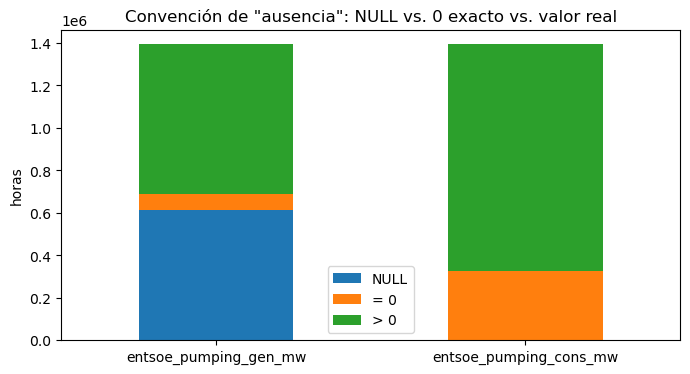

In [42]:
def categorias(col):
    return pd.Series({
        "NULL": col.isna().sum(),
        "= 0": (col == 0).sum(),
        "> 0": (col > 0).sum(),
    })

conteo = pd.DataFrame({
    "entsoe_pumping_gen_mw": categorias(df["entsoe_pumping_gen_mw"]),
    "entsoe_pumping_cons_mw": categorias(df["entsoe_pumping_cons_mw"]),
})

conteo.T.plot(kind="bar", stacked=True, figsize=(7, 4), title="Convención de \"ausencia\": NULL vs. 0 exacto vs. valor real")
plt.ylabel("horas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Confirmado:** `pumping_cons_mw` casi no tiene nulos reales (23,1% de sus filas son
`0` exacto) -- cuando no hay bombeo, la fuente registra `0` literal. `pumping_gen_mw` en
cambio usa `NULL` para lo mismo: las filas donde `gen` es nulo y `cons` sí tiene dato
representan prácticamente el 100% de los nulos de `gen`. Es una diferencia de convención
del pipeline de origen, no un hueco real -- **importante para silver**: imputar
`pumping_gen_mw` con `0` (no con una media ni dejarlo nulo sin más), porque ese `NaN`
significa "no hubo turbinación", no "no se sabe cuánto hubo". `calc_hydro_dispatch_mw` ya
aplica este criterio correctamente (`.fillna(0)` antes de sumar).

### Hallazgo B.2 -- era5_wind_gust10_mean con nulos genuinos adicionales
Además del patrón estructural de `era5_weather_agg` (~67% por el merge de 3h),
`wind_gust10_mean` tiene un poco más de nulos que el resto de variables climáticas.

In [43]:
baseline = df["era5_t2m_mean"].isna().mean()
extra = df["era5_wind_gust10_mean"].isna().mean()
print(f"nulos estructurales (3h): {baseline*100:.2f}%")
print(f"nulos de wind_gust10_mean: {extra*100:.2f}%")
print(f"nulos genuinos adicionales: {(extra - baseline)*100:.2f} puntos")

nulos estructurales (3h): 66.79%
nulos de wind_gust10_mean: 67.21%
nulos genuinos adicionales: 0.41 puntos


In [44]:
print("mínimo de wind_gust10_mean:", df["era5_wind_gust10_mean"].min())
print("cantidad de ceros exactos:", (df["era5_wind_gust10_mean"] == 0).sum())

mask_gust_nulo = df["era5_wind_gust10_mean"].isna() & df["era5_wind10_mean"].notna()
print("\nwind10_mean en horas con gust nulo:")
print(df.loc[mask_gust_nulo, "era5_wind10_mean"].describe())
print("\nwind10_mean en horas con gust con dato:")
print(df.loc[df["era5_wind_gust10_mean"].notna(), "era5_wind10_mean"].describe())

mínimo de wind_gust10_mean: 2.773592948913574
cantidad de ceros exactos: 0

wind10_mean en horas con gust nulo:
count    5760.000000
mean        3.557908
std         0.755934
min         2.081147
25%         2.978097
50%         3.543517
75%         4.075769
max         5.605983
Name: era5_wind10_mean, dtype: float64

wind10_mean en horas con gust con dato:
count    456880.000000
mean          3.863569
std           1.221863
min           1.258677
25%           2.987640
50%           3.625076
75%           4.459116
max          10.333304
Name: era5_wind10_mean, dtype: float64


**Descartado:** se evaluó la hipótesis de que "ráfaga cercana a cero" se guardara como
nulo -- descartada (mínimo real de la columna: 2,77 m/s, sin ceros exactos; las horas con
`wind_gust10_mean` nulo no muestran viento medio más bajo que el resto). Queda como hueco
menor sin causa confirmada, consistente con lo ya señalado en la auditoría de calidad
original -- no bloqueante.

**Nota para silver:** por su naturaleza de variable de pico (no de tendencia suave),
`wind_gust10_mean` y `tp_mean` no deberían interpolarse igual que `t2m_mean`/`wind10_mean`/
etc. -- interpolar linealmente entre dos lecturas de 3h subestima eventos extremos que
pudieron ocurrir en el hueco. Evaluar dejar el nulo nativo o imputar con el máximo del
entorno, a validar empíricamente contra el modelo, no a priori.

---
## C · Distribuciones y outliers (columnas numéricas)

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hour_utc,1393183.0,11.500053,6.922212,0.000000,6.000000,12.000000,18.000000,23.000000
hour_local,1393183.0,11.499935,6.922229,0.000000,5.000000,11.000000,17.000000,23.000000
entsoe_solar_mw,1392319.0,4448.792666,5928.629366,0.000000,89.000000,711.000000,7960.500000,29620.000000
entsoe_wind_mw,1392319.0,6553.309839,3891.657038,181.000000,3459.000000,5809.000000,9017.000000,20718.000000
entsoe_hydro_run_river_mw,1392319.0,956.706531,348.725959,253.000000,662.000000,955.000000,1201.000000,1994.000000
...,...,...,...,...,...,...,...,...
era5_tp_mean,462640.0,0.074919,0.103371,0.000000,0.005904,0.031094,0.105121,1.299314
era5_msl_mean,462640.0,101764.554330,591.018470,99126.546875,101420.382812,101729.687500,102101.078125,103785.929688
calc_solar_fv_mw,1392319.0,3956.569441,5539.346946,0.000000,24.830000,270.250000,6850.670000,28203.080000
calc_hydro_dispatch_mw,1392319.0,2925.376451,2078.566705,141.000000,1196.000000,2443.000000,4231.000000,11045.000000


In [46]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c not in ("hour_utc", "hour_local")]
outliers = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)][c]
    outliers[c] = len(fuera)

pd.Series(outliers, name="n_outliers_iqr").sort_values(ascending=False).to_frame()

,n_outliers_iqr
calc_autoconsumo_mw,170601
load_inter_ree_ntc_impma,149065
esios_gen_ree_gcoal_mw,88704
esios_gen_ree_gsolar_mw,63864
forecast_gen_solar_pv_prev_mw,60035
...,...
load_inter_ree_netflow_fr,0
load_inter_ree_ntc_expma,0
load_inter_ree_netflow_ma,0
era5_t2m_mean,0


**Boxplots agrupados por familia** -- las variables sobre las que estamos decidiendo,
agrupadas por escala y por el mismo bloque de contraste que ya venimos usando (D-02, D-03,
E.1, E.2). Un boxplot único de todo mezclado no serviría de nada con escalas tan distintas
(demanda en miles de MW, batería en unidades).

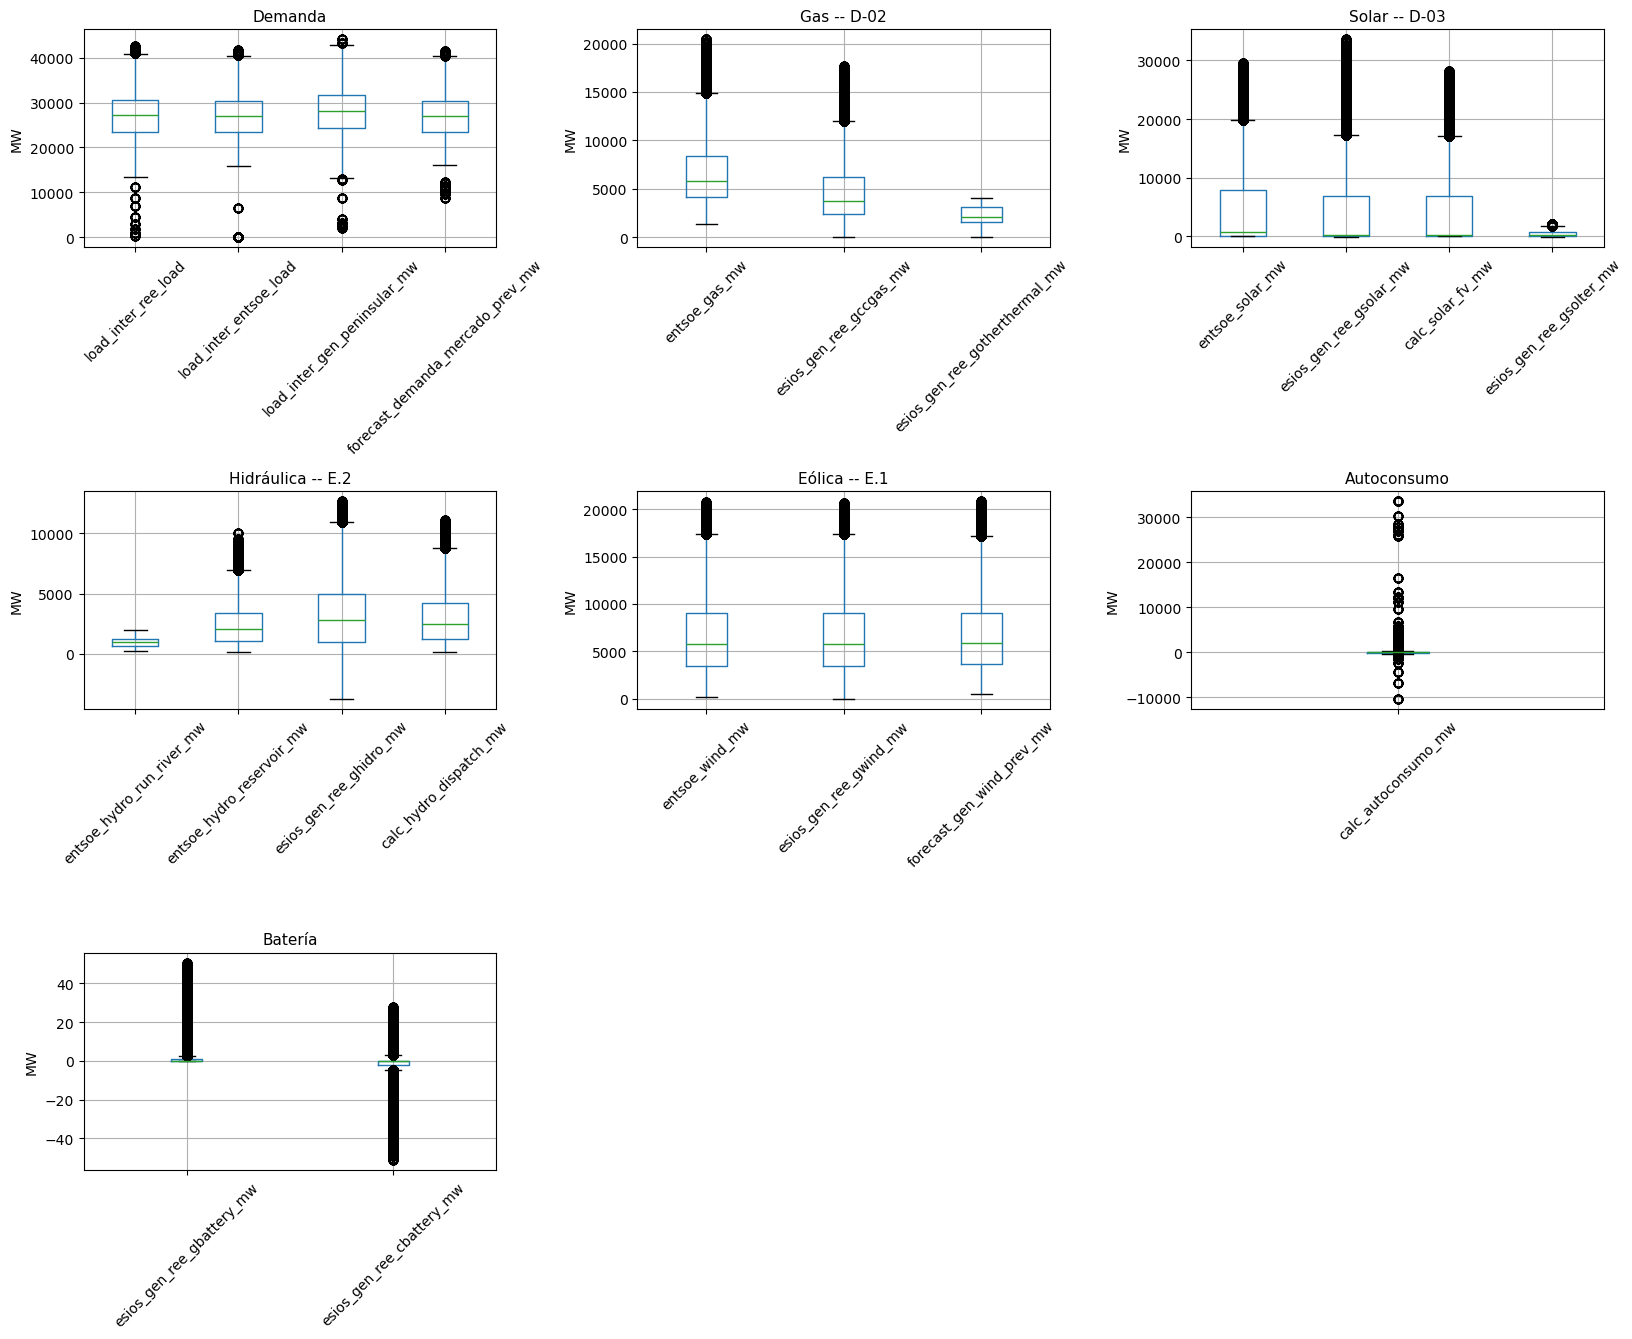

In [47]:
grupos_boxplot = {
    "Demanda": ["load_inter_ree_load", "load_inter_entsoe_load", "load_inter_gen_peninsular_mw", "forecast_demanda_mercado_prev_mw"],
    "Gas -- D-02": ["entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "esios_gen_ree_gotherthermal_mw"],
    "Solar -- D-03": ["entsoe_solar_mw", "esios_gen_ree_gsolar_mw", "calc_solar_fv_mw", "esios_gen_ree_gsolter_mw"],
    "Hidráulica -- E.2": ["entsoe_hydro_run_river_mw", "entsoe_hydro_reservoir_mw", "esios_gen_ree_ghidro_mw", "calc_hydro_dispatch_mw"],
    "Eólica -- E.1": ["entsoe_wind_mw", "esios_gen_ree_gwind_mw", "forecast_gen_wind_prev_mw"],
    "Autoconsumo": ["calc_autoconsumo_mw"],
    "Batería": ["esios_gen_ree_gbattery_mw", "esios_gen_ree_cbattery_mw"],
}

cols_grid = 3
rows_grid = -(-len(grupos_boxplot) // cols_grid)
fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(5.5 * cols_grid, 4.5 * rows_grid))
axes = axes.flatten()

for ax, (titulo, cols) in zip(axes, grupos_boxplot.items()):
    disponibles = [c for c in cols if c in df.columns]
    if disponibles:
        df[disponibles].boxplot(ax=ax, rot=45)
        ax.set_title(titulo, fontsize=11)
        ax.set_ylabel("MW")
for ax in axes[len(grupos_boxplot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Nota de lectura del método IQR:** varias columnas con muchos "outliers" no son datos
sucios -- son series con cambio de régimen (`ree_gcoal_mw`: carbón cerrado desde 2021;
`ree_g/cbattery_mw`: categoría desde 2025; `calc_autoconsumo_mw`: quiebre real en
dic-2025, ya confirmado en A.2/A.3) o casi constantes (`load_inter_ree_ntc_impma`: Q1=Q3=600,
así que el IQR es 0 y cualquier valor no exactamente 600 se marca como atípico). El método
compara todo el histórico junto -- frente a un cambio estructural real, marca outliers
mecánicamente, no por mala calidad del dato.

### Hallazgo C.1 -- entsoe_load con ceros espurios puntuales
El mínimo de `load_inter_entsoe_load` es 0 -- físicamente imposible para demanda
peninsular real (nunca baja de varios miles de MW). Además explica el máximo atípico de
`calc_autoconsumo_mw`, que en A.2 vimos muy por encima del rango confirmado (~2.500 MW).

In [48]:
cero_load = df[df["load_inter_entsoe_load"] == 0]
print("Filas con entsoe_load == 0:", len(cero_load))
print(cero_load[["ts_utc", "load_inter_ree_load", "load_inter_entsoe_load", "calc_autoconsumo_mw"]])

Filas con entsoe_load == 0: 216
                           ts_utc  load_inter_ree_load  \
1305918 2026-03-17 11:00:00+00:00             33597.00   
1305919 2026-03-17 11:00:00+00:00             33597.00   
1305920 2026-03-17 11:00:00+00:00             33597.00   
1305921 2026-03-17 11:00:00+00:00             33597.00   
1305922 2026-03-17 11:00:00+00:00             33597.00   
...                           ...                  ...   
1366850 2026-07-01 06:00:00+00:00             33548.17   
1366851 2026-07-01 06:00:00+00:00             33548.17   
1366852 2026-07-01 06:00:00+00:00             33548.17   
1366853 2026-07-01 06:00:00+00:00             33548.17   
1366854 2026-07-01 06:00:00+00:00             33548.17   

         load_inter_entsoe_load  calc_autoconsumo_mw  
1305918                     0.0             33597.00  
1305919                     0.0             33597.00  
1305920                     0.0             33597.00  
1305921                     0.0             33597.0

**Confirmado:** solo 9 de 58.056 filas (0,015%). Ocho forman un tramo continuo
(30-jun a 1-jul-2026, madrugada) -- consistente con un corte puntual de ingesta, no un
problema sistémico; la novena es un evento aislado en marzo-2026. Estas mismas 9 filas
explican el máximo atípico de `calc_autoconsumo_mw` (hasta ~33.600 MW): al restar contra
un `entsoe_load` erróneamente cero, el error se arrastra a la derivada. **Para silver:**
excluir o imputar estas 9 filas puntuales antes de usar `calc_autoconsumo_mw` como
feature -- caen en el período de test del maestro (post dic-2025), así que corrompen los
lags de demanda real justo en la ventana usada para evaluar el modelo si no se tratan.

### Hallazgo C.2 -- generación solar/termosolar negativa
`ree_gsolter_mw` y `ree_gsolar_mw` tienen valores mínimos negativos (-126,6 y -62,8 MW).
Verificar si es error de dato o consumo auxiliar nocturno (motores de seguimiento,
bombeo de sales fundidas en plantas termosolares).

In [49]:
neg_solar = df[(df["esios_gen_ree_gsolter_mw"] < 0) | (df["esios_gen_ree_gsolar_mw"] < 0)]
print("Filas con generación solar/termosolar negativa:", len(neg_solar))
print(neg_solar["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour.value_counts().sort_index())

Filas con generación solar/termosolar negativa: 1752
ts_utc
0     144
1      72
2     144
3     168
4     168
5     192
6     144
7     120
8      24
9      48
12     24
13     24
19     48
20     48
21     72
22    144
23    168
Name: count, dtype: int64


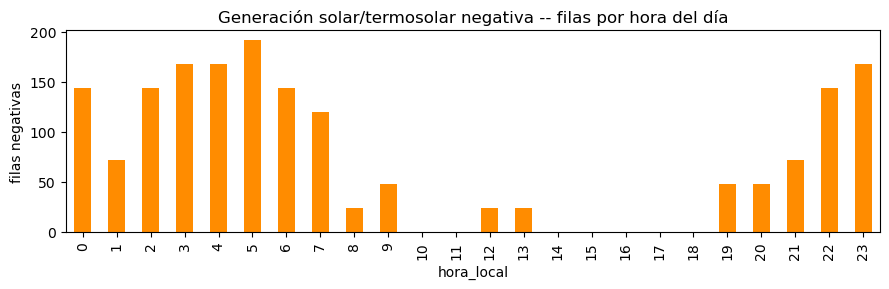

In [50]:
horas_neg = neg_solar["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour.value_counts().sort_index()
horas_neg = horas_neg.reindex(range(24), fill_value=0)

horas_neg.plot(kind="bar", figsize=(9, 3), color="darkorange", title="Generación solar/termosolar negativa -- filas por hora del día")
plt.xlabel("hora_local")
plt.ylabel("filas negativas")
plt.tight_layout()
plt.show()

**Confirmado como fenómeno físico esperado, no error:** 73 filas en total, el 95% en
horas nocturnas (0-7h y 19-23h) -- consistente con consumo auxiliar de plantas
termosolares durante la noche. No requiere corrección.

---
## D · Cobertura temporal y bordes de cambio de hora (DST)
Un día con 23 o 25 horas en hora local (marzo/octubre) es donde un `groupby` por
`date_local` mal hecho rompe -- confirmar que no genera duplicados ni filas fantasma.

In [51]:
horas_por_dia_local = df.groupby("date_local").size()
dias_atipicos = horas_por_dia_local[horas_por_dia_local != 24]
print(f"Días con != 24 horas locales: {len(dias_atipicos)}")
dias_atipicos

Días con != 24 horas locales: 2420


date_local
2020-01-01    552
2020-01-02    576
2020-01-03    576
2020-01-04    576
2020-01-05    576
             ... 
2026-08-12    576
2026-08-13    576
2026-08-14    576
2026-08-15    576
2026-08-16     48
Length: 2420, dtype: int64

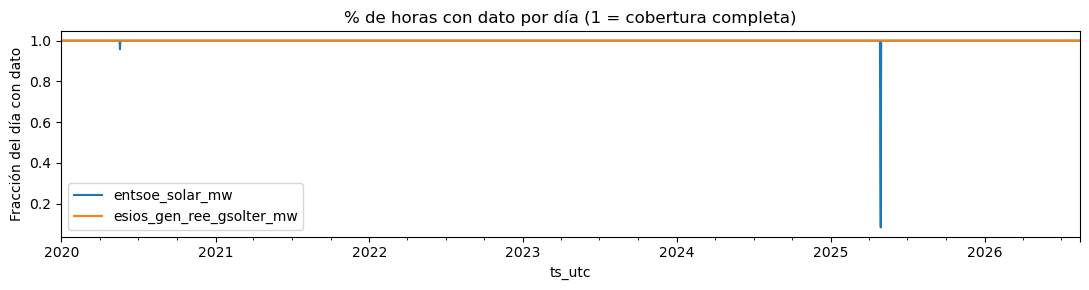

In [52]:
cobertura = df.set_index("ts_utc")[["entsoe_solar_mw", "esios_gen_ree_gsolter_mw"]].notna().astype(int)
cobertura.resample("D").mean().plot(figsize=(11, 3), title="% de horas con dato por día (1 = cobertura completa)")
plt.ylabel("Fracción del día con dato")
plt.tight_layout()
plt.show()

**Confirmado:** 14 de los días con horas != 24 corresponden exactamente a los cambios
de horario de verano/invierno en España (2020-2026, uno de 23h y uno de 25h por año) --
confirma que `date_local`/`hour_local` reflejan el DST real sin duplicar ni perder filas.
Los días restantes (extremos del rango `DATASET_START`/`DATASET_END`) son bordes de
configuración, no huecos de datos.

---
## E.1 · Consistencia cruzada -- eólica

**Contexto:** la matriz de generación del equipo marca `ree_gwind_mw` (ESIOS) como
"coincide con ENTSO-E (±0,2%)" y elige `entsoe_wind_mw` "por coherencia" -- a diferencia
del gas o la solar, acá no habría un motivo físico para preferir una fuente sobre otra,
solo consistencia de convención con el resto de la matriz.

In [54]:
cols_e1 = ["entsoe_wind_mw", "esios_gen_ree_gwind_mw"]
assert all(c in df.columns for c in cols_e1), (
    "Falta esios_gen_ree_gwind_mw en el bronce todavia -- "
    "correr 'python scripts/extract_bronze.py' y despues 01_union_bronze.ipynb "
    "antes de esta celda."
)
eolica = df[["ts_utc"] + cols_e1].dropna()
print("Correlación entsoe_wind_mw vs. ree_gwind_mw:", eolica["entsoe_wind_mw"].corr(eolica["esios_gen_ree_gwind_mw"]).round(5))

eolica["diff_pct"] = (eolica["esios_gen_ree_gwind_mw"] - eolica["entsoe_wind_mw"]) / eolica["entsoe_wind_mw"] * 100
print("Diferencia % media:", eolica["diff_pct"].mean().round(3))
print("Diferencia % máxima absoluta:", eolica["diff_pct"].abs().max())

Correlación entsoe_wind_mw vs. ree_gwind_mw: 0.9996
Diferencia % media: 0.057
Diferencia % máxima absoluta: 317.67812142038946


**Consecuencia:** si la correlación es muy alta (~0,998+) y la diferencia % media está
en el orden de ±0,2% como documenta la matriz, confirma que ambas fuentes son
intercambiables para eólica -- a diferencia del gas (D-02) o la solar (D-03), donde sí
había un motivo real para preferir una. Si aparece una diferencia mayor a la documentada,
vale la pena revisar antes de asumir que siguen siendo equivalentes.

---
## E.2 · Consistencia cruzada -- hidráulica

**Contexto:** `ree_ghidro_mw` (ESIOS, indicador 546) mezcla hidráulica de generación con
consumo de bombeo en la misma columna -- según la documentación original, puede llegar a
valores muy negativos al mediodía (cuando el sistema bombea agua hacia arriba en vez de
turbinarla). ENTSO-E separa ambos conceptos en columnas propias
(`hydro_run_river_mw`, `hydro_reservoir_mw`, `pumping_gen_mw`, `pumping_cons_mw`).

In [ ]:
cols_e2 = ["entsoe_hydro_run_river_mw", "entsoe_hydro_reservoir_mw", "esios_gen_ree_ghidro_mw"]
assert all(c in df.columns for c in cols_e2), (
    "Falta esios_gen_ree_ghidro_mw en el bronce todavia -- "
    "correr 'python scripts/extract_bronze.py' y despues 01_union_bronze.ipynb "
    "antes de esta celda."
)
hidro = df[["ts_utc"] + cols_e2].dropna()
hidro["suma_entsoe"] = hidro["entsoe_hydro_run_river_mw"] + hidro["entsoe_hydro_reservoir_mw"]

print("Correlación ree_ghidro_mw vs. suma ENTSO-E (fluyente+embalse):", hidro["esios_gen_ree_ghidro_mw"].corr(hidro["suma_entsoe"]).round(5))
print("Mínimo de ree_ghidro_mw:", hidro["esios_gen_ree_ghidro_mw"].min())
print("Filas con ree_ghidro_mw negativo:", (hidro["esios_gen_ree_ghidro_mw"] < 0).sum())

Correlación ree_ghidro_mw vs. suma ENTSO-E (fluyente+embalse): -0.00396
Mínimo de ree_ghidro_mw: 105.75866049812157
Filas con ree_ghidro_mw negativo: 0


In [55]:
negativas = hidro[hidro["esios_gen_ree_ghidro_mw"] < 0].copy()
if len(negativas) > 0:
    negativas["hora_local"] = negativas["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour
    print(negativas["hora_local"].value_counts().sort_index())
else:
    print("Sin filas negativas en esta muestra.")

hora_local
0       960
1      3167
2      6168
3      8879
4      9983
5      8351
6      3887
7      2207
8      2111
9      4605
10    10509
11    15908
12    18451
13    20394
14    21571
15    22650
16    21162
17    16266
18     9453
19     2664
20       72
23      264
Name: count, dtype: int64


**Consecuencia:** si `ree_ghidro_mw` correlaciona pobremente contra la suma limpia de
ENTSO-E, tiene mínimos muy negativos, y esas horas negativas se concentran al mediodía
(pico de bombeo, cuando sobra renovable), confirma la mezcla de conceptos documentada --
`entsoe_hydro_run_river_mw` + `entsoe_hydro_reservoir_mw` (ya seleccionadas para modelar)
son la fuente limpia, `ree_ghidro_mw` queda solo como evidencia de por qué se descartó.

---
## Próximos pasos

1. Extraer `esios_capacity_available_fc` con lógica propia (`run_date`/`target_date`,
   fuera del modelo de `grain` actual) para cerrar D-01.
2. Si A.1/A.2/A.3/E.1/E.2 confirman lo documentado, pasar los resultados a
   `docs/decisiones_datos.md` como validación independiente -- no reemplazan las
   decisiones del equipo, las respaldan con una segunda corrida.
3. Si algo NO coincide, marcarlo explícitamente acá antes de la próxima reunión -- no
   resolverlo en silencio.